In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

Q1. Load the cleaned kidney dataset(ckd)dataset and print its type and description

In [7]:
df = pd.read_excel('C:/Users/Asus/Desktop/DL Lab/DL Lab/Assignment 3/ckd_clean1.xlsx')
print(df.dtypes)
print(df.describe())

Age                          int64
Blood Pressure               int64
Specific Gravity           float64
Albumin                      int64
Sugar                        int64
Red Blood Cells             object
Pus Cell                    object
Pus Cell clumps             object
Bacteria                    object
Blood Glucose Random         int64
Blood Urea                   int64
Serum Creatinine           float64
Sodium                       int64
Potassium                  float64
Hemoglobin                 float64
Packed Cell Volume           int64
White Blood Cell Count       int64
Red Blood Cell Count       float64
Hypertension                object
Diabetes Mellitus           object
Coronary Artery Disease     object
Appetite                    object
Pedal Edema                 object
Anemia                      object
Class                        int64
dtype: object
              Age  Blood Pressure  Specific Gravity     Albumin       Sugar  \
count  158.000000      158.00000

Q2. Prepare the data for Logistic Regression
Take Logistic regression in the phyton library. Parameter tuning for optimizing classifier performance set for several parameter values namely: C =1.0, λ = 1.2 C .The default value is 1.0. The smaller C value specifies the stronger regularization value. The Lambda parameter used to control the regularization strength. The increase in the lambda values the strength of the regularization effect.

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
log_reg = LogisticRegression(max_iter=1000)
param_grid = {'C': [0.01, 0.1, 1.0, 10], 'penalty': ['l2']}
grid_search = GridSearchCV(log_reg, param_grid, scoring='accuracy', cv=5)
grid_search.fit(X_train, y_train)
best_params = grid_search.best_params_
print("Best parameters: ", best_params)
categorical_cols = ['Red Blood Cells', 'Pus Cell', 'Pus Cell clumps', 'Bacteria', 'Hypertension', 'Diabetes Mellitus',
                     'Coronary Artery Disease', 'Appetite', 'Pedal Edema', 'Anemia']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str)) 
    label_encoders[col] = le
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Best parameters:  {'C': 0.1, 'penalty': 'l2'}


Logistic Regression without SGD

In [10]:
lr = LogisticRegression(max_iter=1000, C=1.0)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Q3. Confusion Matrix

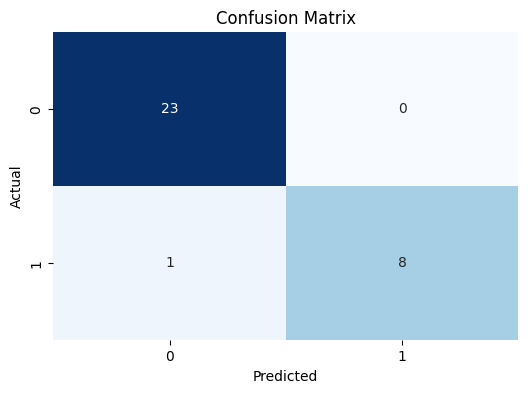

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
log_reg = LogisticRegression(C=best_params['C'], penalty='l2', max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Q4. Accuracy, Precision, F-measure, Recall

In [12]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f_measure = f1_score(y_test, y_pred)
print("Without SGD - Accuracy: {}, Precision: {}, Recall: {}, F-measure: {}".format(accuracy, precision, recall, f_measure))

Without SGD - Accuracy: 0.96875, Precision: 1.0, Recall: 0.8888888888888888, F-measure: 0.9411764705882353


 Q5. Logistic Regression with SGD

In [20]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(loss='log', alpha=0.0001, epsilon=0.1, max_iter=1000, tol=1e
sgd_clf.fit(X_train, y_train)

SyntaxError: invalid syntax (3029210255.py, line 2)

Q6. Confusion Matrix with SGD

In [19]:
y_pred_sgd = sgd_clf.predict(X_test)
cm_sgd = confusion_matrix(y_test, y_pred_sgd)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

NameError: name 'sgd_clf' is not defined

 Q7. Accuracy, Precision, F-measure, Recall with SGD

In [15]:
accuracy_sgd = accuracy_score(y_test, y_pred_sgd)
precision_sgd = precision_score(y_test, y_pred_sgd)
recall_sgd = recall_score(y_test, y_pred_sgd)
f_measure_sgd = f1_score(y_test, y_pred_sgd)
print("With SGD - Accuracy: {}, Precision: {}, Recall: {}, F-measure: {}".format(accuracy_sgd, precision_sgd, recall_sgd, f_measure_sgd))

With SGD - Accuracy: 0.28125, Precision: 0.28125, Recall: 1.0, F-measure: 0.43902439024390244


Q8. Plotting the results

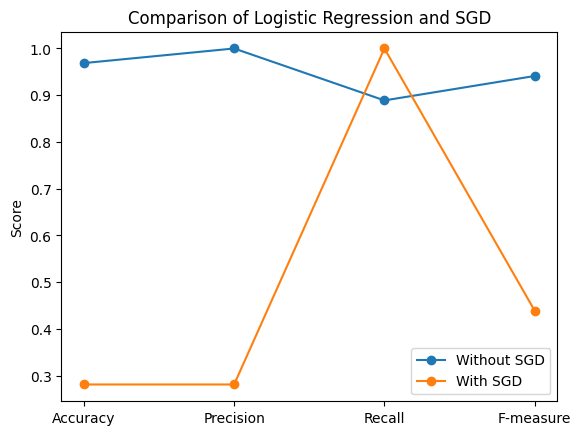

In [16]:
labels = ['Accuracy', 'Precision', 'Recall', 'F-measure']
without_sgd = [accuracy, precision, recall, f_measure]
with_sgd = [accuracy_sgd, precision_sgd, recall_sgd, f_measure_sgd]
x = range(len(labels))
plt.plot(x, without_sgd, label='Without SGD', marker='o')
plt.plot(x, with_sgd, label='With SGD', marker='o')
plt.xticks(x, labels)
plt.ylabel('Score')
plt.title('Comparison of Logistic Regression and SGD')
plt.legend()
plt.show()